<a href="https://colab.research.google.com/github/Vishnuprabhasreddy/household_power_consumption/blob/main/household_power_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

               Date      Time Global_active_power Global_reactive_power  \
0        16/12/2006  17:24:00               4.216                 0.418   
1        16/12/2006  17:25:00               5.360                 0.436   
2        16/12/2006  17:26:00               5.374                 0.498   
3        16/12/2006  17:27:00               5.388                 0.502   
4        16/12/2006  17:28:00               3.666                 0.528   
...             ...       ...                 ...                   ...   
1861031    1/7/2010  02:35:00               0.366                 0.180   
1861032    1/7/2010  02:36:00               0.290                 0.072   
1861033    1/7/2010  02:37:00               0.276                 0.052   
1861034    1/7/2010  02:38:00               0.532                 0.126   
1861035    1/7/2010       NaN                 NaN                   NaN   

         Voltage Global_intensity Sub_metering_1 Sub_metering_2  \
0        234.840           18.40

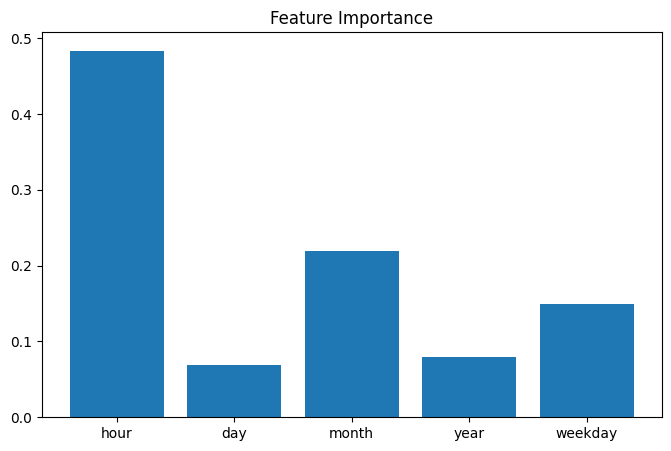

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Load Dataset
df = pd.read_csv("household_power_consumption.txt",
                 sep=';',
                 low_memory=False)
print(df)

# Replace missing values
df.replace('?', np.nan, inplace=True)

# Convert target column
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

# Remove null values
df.dropna(inplace=True)

# Combine date and time
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)
print(df)
# Feature Engineering
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year
df['weekday'] = df['Datetime'].dt.weekday

# Features
X = df[['hour', 'day', 'month', 'year', 'weekday']]

# Target
y = df['Global_active_power']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Feature Importance
importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.show()